## Импортирование необходимых библиотек

In [1]:
from PIL import Image
from glob import glob
import time
import numpy as np
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, Dataset, DataLoader
from torchsummary import summary
from torchvision import transforms as T
from tensorflow import summary as tfsummary
import pickle
from sklearn.metrics import classification_report
from PIL import Image
from tqdm.auto import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt
import os

2025-01-20 16:45:43.595891: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1737380743.669599   21468 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1737380743.689551   21468 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-20 16:45:43.770879: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/darya/Документы/GitHub/backend_plants/ml_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not 

## Чтение тренировочной и тестовой выборки

In [2]:
heigth_width = 32

# CLASSES = ['бархатцы', 'вербена', 'герань', 'гиацинт', 'глициния', 'декоративная трава','жимолость','клематис','космея']
# CLASSES = ['бархатцы', 'вербена', 'герань', 'папортоник'] 
CLASSES = ['алоэ', 'бархатцы', 'вербена', 'герань', 'гиацинт', 'глициния', 'декоративная трава',\
           'дуб','ель', 'жимолость','ирис','кактус','клематис','клен','космея', 'лилии', \
            'можжевельник','монарда','нарцисс','орхидея','папоротники', 'пион', 'плющ',\
            'рододендрон','сансевиерия', 'сосна', 'суккулент','тюльпан', 'циния', 'эхинацея', 'яблоня'] 

images = []
images_t = []
classes = []
classes_t = []

for CLASS in range(0, len(CLASSES)):
  path_class = "/home/darya/Документы/GitHub/backend_plants/ML/%s/*.*"%CLASSES[CLASS]

    
  for photo in glob(path_class):
      img = Image.open(photo).convert('RGB')
      img = img.resize((heigth_width, heigth_width), Image.LANCZOS)
      
      # Создание 15 дубликатов
      for _ in range(15):
          images.append(np.asarray(img))
          classes.append(np.asarray(CLASS))

# Теперь у вас есть базовые данные с дубликатами
# Перемешиваем изображения:
indices = np.random.permutation(len(images))
images = [images[i] for i in indices]
classes = [classes[i] for i in indices]

# Разделение на обучающую и тестовую выборки
split_index = int(len(images) * 0.8)
train_X = np.array(images[:split_index])
train_y = np.array(classes[:split_index])
test_X = np.array(images[split_index:])
test_y = np.array(classes[split_index:])

# Проверка размеров выборок
print("Train size:", len(train_X))
print("Test size:", len(test_X))

Train size: 117240
Test size: 29310


In [20]:
print(len(CLASSES))

31


###Приведение фотографий к требуемому размеру

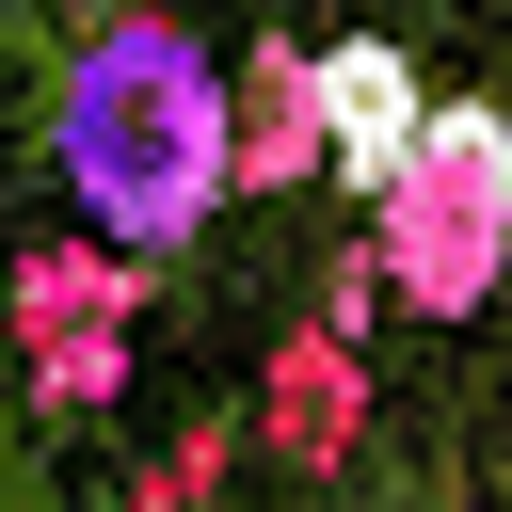

In [3]:
Image.fromarray(train_X[2]).resize((512,512))

In [4]:
print(train_y[1])

11


In [5]:

transform = T.Compose([
     T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.2, hue=0.0),
     T.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.8, 1.2),
                    shear=5),
])



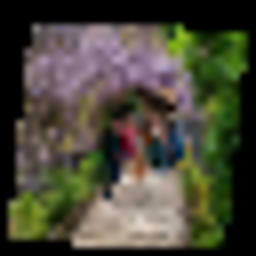

In [6]:
Image.fromarray((transform(torch.Tensor(train_X[50]).permute(2, 0, 1)/255.).\
                 permute(1, 2, 0).numpy()*255.).astype(np.uint8)).\
                 resize((256, 256))

In [7]:
# Применяем трансформации ко всем изображениям train_X
for i in range(len(train_X)):
    img_tensor = transform(torch.Tensor(train_X[i]).permute(2, 0, 1) / 255.)  # Преобразуем в тензор и нормализуем
    train_X[i] = (img_tensor.permute(1, 2, 0).numpy() * 255.).astype(np.uint8)  # Записываем обратно в train_X

# Применяем трансформации ко всем изображениям test_X
# for i in range(len(test_X)):
#     img_tensor = transform(torch.Tensor(test_X[i]).permute(2, 0, 1) / 255.)
#     test_X[i] = (img_tensor.permute(1, 2, 0).numpy() * 255.).astype(np.uint8)  # Записываем обратно в test_X

In [8]:


# Сохранение массивов в файлы
np.save('train_X.npy', train_X)
np.save('train_y.npy', train_y)
np.save('test_X.npy', test_X)
np.save('test_y.npy', test_y)

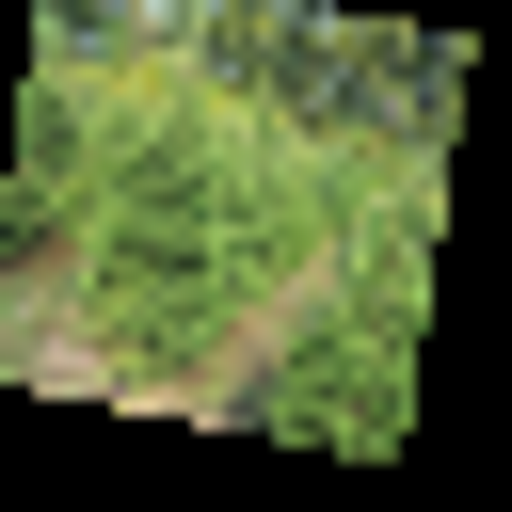

In [9]:
Image.fromarray(train_X[3]).resize((512,512))

##Создание Pytorch DataLoader'a

In [21]:

batch_size = 128
dataloader = {}
for (X, y), part in zip([(train_X, train_y), (test_X, test_y)],
                        ['train', 'test']):
    tensor_x = torch.Tensor(X)
    tensor_y = F.one_hot(torch.Tensor(y).to(torch.int64),
                                     num_classes=len(CLASSES))/1.
    dataset = TensorDataset(tensor_x, tensor_y) # создание объекта датасета
    dataloader[part] = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=3) # создание экземпляра класса DataLoader
dataloader

{'train': <torch.utils.data.dataloader.DataLoader at 0x7d44e2cfda00>,
 'test': <torch.utils.data.dataloader.DataLoader at 0x7d4468205820>}

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class Normalize(nn.Module):
    def __init__(self, mean, std):
        super(Normalize, self).__init__()
        self.mean = torch.tensor(mean).to(device)
        self.std = torch.tensor(std).to(device)

    def forward(self, input):
        x = input / 255.0
        x = x - self.mean
        x = x / self.std
        return x.permute(0, 3, 1, 2) # nhwc -> nm

model = torch.hub.load("chenyaofo/pytorch-cifar-models",
                       #"cifar100_mobilenetv2_x0_5",
                       'cifar100_resnet20',
                       pretrained=True)
model.to(device)
new_model = nn.Sequential(
    Normalize([0.5074,0.4867,0.4411],[0.2011,0.1987,0.2025]),# https://blog.jovian.ai/image-classification-of-cifar100-dataset-using-pytorch-8b7145242df1
    model
).to(device)
print(new_model(torch.rand(1, 32, 32, 3).to(device)))
# summary(new_model, input_size=(32, 32, 3))
new_model

tensor([[-1.6106, -0.2043,  0.4385,  0.6939,  0.5437, -0.8577, -0.8522,  0.7443,
         -0.0412,  0.5013,  1.2767,  0.7976, -0.2554, -0.3767,  0.2347,  0.3237,
          0.1718, -0.5646,  0.6276,  0.5118, -0.8823, -1.1034,  0.4527, -0.7210,
         -0.8838,  1.4484, -0.1233, -0.8778, -0.8566,  1.4742, -1.0059,  0.2550,
          1.4891,  0.7643, -0.0029,  0.6150, -0.1744,  0.3023,  0.1843, -0.7471,
          1.4218,  0.0390,  0.6370, -1.5504,  1.1446,  0.9837,  1.0108, -1.0865,
         -0.3967, -0.7157,  1.3031,  0.4754, -1.3382, -2.2078, -0.7993,  0.4543,
         -0.3867,  1.0234, -2.0067,  0.2181, -1.2769, -0.9368, -0.0511,  0.5731,
          1.0186,  0.7742,  0.5174,  1.3348, -0.4540, -0.1179, -1.0691, -1.0488,
          1.5216,  1.0284,  0.5571,  0.1170, -0.8040, -0.0140,  0.8330,  0.3631,
          0.0212, -1.1480,  0.1279, -0.3933,  0.4593, -0.0635, -0.9204,  0.8045,
         -0.2775,  0.0172,  0.2592,  0.6337, -0.0967,  0.5439, -1.9261, -1.4453,
          0.4303, -0.4853,  

Using cache found in /home/darya/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


Sequential(
  (0): Normalize()
  (1): CifarResNet(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): 

In [23]:
## mobilenetv2
#in_features = new_model[1].classifier[1].in_features
#new_model[1].classifier[1] = nn.Linear(in_features=in_features,
#                                       out_features=len(CLASSES),
#                                       bias=True)
## resnet20
in_features = new_model[1].fc.in_features
new_model[1].fc = nn.Linear(in_features=in_features,
                            out_features=len(CLASSES),
                            bias=True)

new_model.to(device)
summary(new_model, input_size=(32, 32, 3))
print(new_model(torch.rand(1, 32, 32, 3).to(device)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
         Normalize-1            [-1, 3, 32, 32]               0
            Conv2d-2           [-1, 16, 32, 32]             432
       BatchNorm2d-3           [-1, 16, 32, 32]              32
              ReLU-4           [-1, 16, 32, 32]               0
            Conv2d-5           [-1, 16, 32, 32]           2,304
       BatchNorm2d-6           [-1, 16, 32, 32]              32
              ReLU-7           [-1, 16, 32, 32]               0
            Conv2d-8           [-1, 16, 32, 32]           2,304
       BatchNorm2d-9           [-1, 16, 32, 32]              32
             ReLU-10           [-1, 16, 32, 32]               0
       BasicBlock-11           [-1, 16, 32, 32]               0
           Conv2d-12           [-1, 16, 32, 32]           2,304
      BatchNorm2d-13           [-1, 16, 32, 32]              32
             ReLU-14           [-1, 16,

# Заморозка весов

In [26]:
print("Обучаемые параметры:")
keep_last = 14
total = len([*new_model.named_parameters()])
params_to_update = []
for i, (name, param) in enumerate(new_model.named_parameters()):
    if i < total - keep_last:
        param.requires_grad = False
    else:
        params_to_update.append(param)
        param.requires_grad = True
        print("\t",name)
summary(new_model, input_size=(32, 32, 3))

Обучаемые параметры:
	 1.layer3.1.conv1.weight
	 1.layer3.1.bn1.weight
	 1.layer3.1.bn1.bias
	 1.layer3.1.conv2.weight
	 1.layer3.1.bn2.weight
	 1.layer3.1.bn2.bias
	 1.layer3.2.conv1.weight
	 1.layer3.2.bn1.weight
	 1.layer3.2.bn1.bias
	 1.layer3.2.conv2.weight
	 1.layer3.2.bn2.weight
	 1.layer3.2.bn2.bias
	 1.fc.weight
	 1.fc.bias
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
         Normalize-1            [-1, 3, 32, 32]               0
            Conv2d-2           [-1, 16, 32, 32]             432
       BatchNorm2d-3           [-1, 16, 32, 32]              32
              ReLU-4           [-1, 16, 32, 32]               0
            Conv2d-5           [-1, 16, 32, 32]           2,304
       BatchNorm2d-6           [-1, 16, 32, 32]              32
              ReLU-7           [-1, 16, 32, 32]               0
            Conv2d-8           [-1, 16, 32, 32]           2,304
       BatchNorm2d-9    

# Fine tunning

In [27]:
# добавляем сглаживание целевых меток, это увеличит значение функции потерь
# но полученная модель будет более устойчивой к выбросам в обучающей выборке
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
# используется SGD c momentum и L2-регуляризацией весов
optimizer = optim.SGD(params_to_update, lr=0.01, momentum=0.9,
                      weight_decay=1e-5)
# добавляем постепенное уменьшение шага обучения каждые 20 эпох
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

Эпоха: 10
Лучшая доля правильных ответов: 94.88924844400331
Текущая доля правильных ответов: 94.88924844400331


100%|██████████| 9160/9160 [1:15:34<00:00,  2.02it/s]


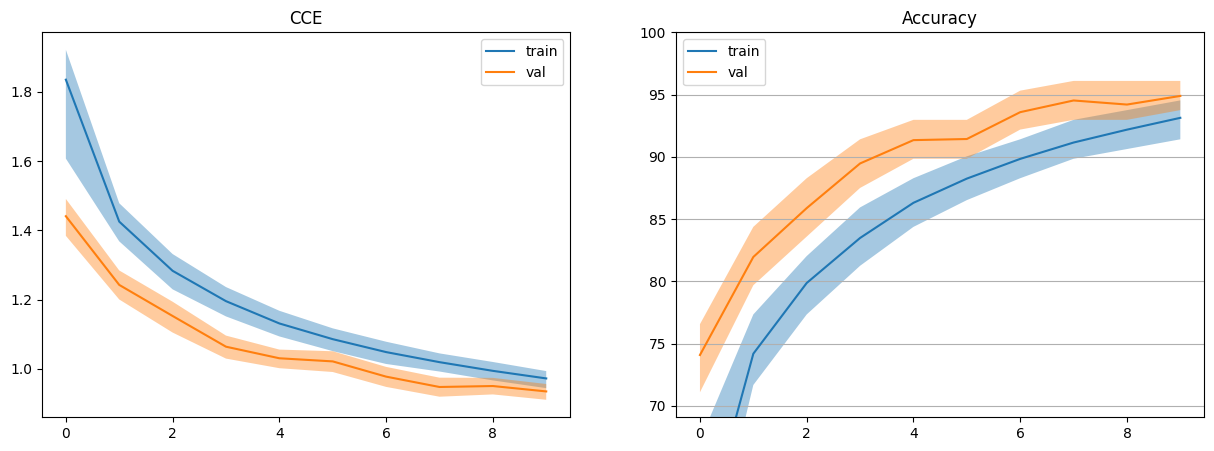

Обучение закончено за 4534.72664475441 секунд


/tmp/ipykernel_21468/2024481918.py:89: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  new_model.load_state_dict(torch.load(checkpoint_path))


In [28]:
EPOCHS = 10
REDRAW_EVERY = 1
steps_per_epoch = len(dataloader['train'])
steps_per_epoch_val = len(dataloader['test'])
# NEW
pbar = tqdm(total=EPOCHS*steps_per_epoch)
losses = []
losses_val = []
passed = 0
# для создания чекпоинта
best_acc = 0
checkpoint_path = 'cifar_cnn_fine.pth'
for epoch in range(EPOCHS):  # проход по набору данных несколько раз
    tmp = []
    new_model.train()
    for i, batch in enumerate(dataloader['train'], 0):
        # получение одного минибатча; batch это двуэлементный список из [inputs, labels]
        inputs, labels = batch
        # на GPU
        inputs, labels = inputs.to(device), labels.to(device)

        # очищение прошлых градиентов с прошлой итерации
        optimizer.zero_grad()

        # прямой + обратный проходы + оптимизация
        outputs = new_model(inputs)
        loss = criterion(outputs, labels)
        #loss = F.cross_entropy(outputs, labels)
        loss.backward()
        optimizer.step()

        # для подсчёта статистик
        accuracy = (labels.detach().argmax(dim=-1)==outputs.detach().argmax(dim=-1)).\
                    to(torch.float32).mean().cpu()*100
        tmp.append((loss.item(), accuracy.item()))
        pbar.update(1)
    losses.append((np.mean(tmp, axis=0),
                   np.percentile(tmp, 25, axis=0),
                   np.percentile(tmp, 75, axis=0)))
    scheduler.step() # обновляем learning_rate каждую эпоху
    tmp = []
    new_model.eval()
    with torch.no_grad(): # отключение автоматического дифференцирования
        for i, data in enumerate(dataloader['test'], 0):
            inputs, labels = data
            # на GPU
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = new_model(inputs)
            loss = criterion(outputs, labels)
            accuracy = (labels.argmax(dim=-1)==outputs.argmax(dim=-1)).\
                        to(torch.float32).mean().cpu()*100
            tmp.append((loss.item(), accuracy.item()))
    losses_val.append((np.mean(tmp, axis=0),
                       np.percentile(tmp, 25, axis=0),
                       np.percentile(tmp, 75, axis=0)))
    # сохранение чекпоинта
    acc = losses_val[-1][0][1]
    if acc > best_acc:
        best_acc = acc
        torch.save(new_model.state_dict(), checkpoint_path)
    # обновление графиков
    if (epoch+1) % REDRAW_EVERY != 0:
        continue
    clear_output(wait=False)
    print('Эпоха: %s\n'
          'Лучшая доля правильных ответов: %s\n'
          'Текущая доля правильных ответов: %s' % (epoch+1, best_acc, acc))
    passed += pbar.format_dict['elapsed']
    pbar = tqdm(total=EPOCHS*steps_per_epoch, miniters=5)
    pbar.update((epoch+1)*steps_per_epoch)
    x_vals = np.arange(epoch+1)
    _, ax = plt.subplots(1, 2, figsize=(15, 5))
    stats = np.array(losses)
    stats_val = np.array(losses_val)
    ax[1].set_ylim(stats_val[:, 0, 1].min()-5, 100)
    ax[1].grid(axis='y')
    for i, title in enumerate(['CCE', 'Accuracy']):
        ax[i].plot(x_vals, stats[:, 0, i], label='train')
        ax[i].fill_between(x_vals, stats[:, 1, i],
                           stats[:, 2, i], alpha=0.4)
        ax[i].plot(x_vals, stats_val[:, 0, i], label='val')
        ax[i].fill_between(x_vals,
                           stats_val[:, 1, i],
                           stats_val[:, 2, i], alpha=0.4)
        ax[i].legend()
        ax[i].set_title(title)
    plt.show()
new_model.load_state_dict(torch.load(checkpoint_path))
print('Обучение закончено за %s секунд' % passed)

In [29]:

batch_size = 64
dataloader = {}
for (X, y), part in zip([(train_X, train_y), (test_X, test_y)],
                        ['train', 'test']):
    tensor_x = torch.Tensor(X)
    tensor_y = F.one_hot(torch.Tensor(y).to(torch.int64),
                                     num_classes=len(CLASSES))/1.
    dataset = TensorDataset(tensor_x, tensor_y) # создание объекта датасета
    dataloader[part] = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=3) # создание экземпляра класса DataLoader
dataloader

{'train': <torch.utils.data.dataloader.DataLoader at 0x7d4463fbce00>,
 'test': <torch.utils.data.dataloader.DataLoader at 0x7d4463fbfb60>}

In [40]:
for part in ['train', 'test']:
    y_pred = []
    y_true = []
    with torch.no_grad(): # отключение автоматического дифференцирования
        for i, data in enumerate(dataloader[part], 0):
            inputs, labels = data
             # на GPU
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = new_model(inputs).detach().cpu().numpy()
            y_pred.append(outputs)
            y_true.append(labels.cpu().numpy())
        y_true = np.concatenate(y_true)
        y_pred = np.concatenate(y_pred)
        print(part)
        print("$$$$$$$$$", len(y_true))
        print("$$$$$$$$$", len(y_pred))
        print("$$$$$$$$$",list(map(str, CLASSES)))
        print(classification_report(y_true.argmax(axis=-1), y_pred.argmax(axis=-1),
                                    digits=4, target_names=list(map(str, CLASSES))))
        print('-'*50)

train
$$$$$$$$$ 117240
$$$$$$$$$ 117240
$$$$$$$$$ ['алоэ', 'бархатцы', 'вербена', 'герань', 'гиацинт', 'глициния', 'декоративная трава', 'дуб', 'ель', 'жимолость', 'ирис', 'кактус', 'клематис', 'клен', 'космея', 'лилии', 'можжевельник', 'монарда', 'нарцисс', 'орхидея', 'папоротники', 'пион', 'плющ', 'рододендрон', 'сансевиерия', 'сосна', 'суккулент', 'тюльпан', 'циния', 'эхинацея', 'яблоня']


ValueError: Number of classes, 30, does not match size of target_names, 31. Try specifying the labels parameter

In [74]:
# сохраниение модели
# ПЕРВЫЙ СПОСОБ: сохранение параметров
PATH = 'cifar_cnn_fine.pth'
torch.save(new_model.state_dict(), PATH)

# ВТОРОЙ СПОСОБ: сохранение всей архитектуры
PATH2 = 'cifar_cnn_fine.pt'
torch.save(new_model, PATH2)
# загрузка
new_model_2 = torch.load(PATH2)
new_model_2.eval()

/tmp/ipykernel_19898/4171029381.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  new_model_2 = torch.load(PATH2)


Sequential(
  (0): Normalize()
  (1): CifarResNet(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): 

In [75]:
# входной тензор для модели
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
x = torch.randn(1, 32, 32, 3, requires_grad=True).to(device)
torch_out = new_model(x)

# экспорт модели
torch.onnx.export(new_model,               # модель
                  x,                   # входной тензор (или кортеж нескольких тензоров)
                  "cifar100_2.onnx", # куда сохранить (либо путь к файлу либо fileObject)
                  export_params=True,  # сохраняет веса обученных параметров внутри файла модели
                  opset_version=9,     # версия ONNX
                  do_constant_folding=True,  # следует ли выполнять укорачивание констант для оптимизации
                  input_names = ['input'],   # имя входного слоя
                  output_names = ['output'],  # имя выходного слоя
                  dynamic_axes={'input' : {0 : 'batch_size'},    # динамичные оси, в данном случае только размер пакета
                                'output' : {0 : 'batch_size'}})